# Load and compare wet mode analysis

Analysis log

## Testing the consequence on the beam case from Alba (2025) paper

In [9]:
using Pkg
Pkg.activate("/home/shagun/Acads/HydroElasticFEM.jl")

using HydroElasticFEM

PKG_ROOT = HydroElasticFEM.PKG_ROOT

  Activating project at `~/Acads/HydroElasticFEM.jl`


"/home/shagun/Acads/HydroElasticFEM.jl/"

In [10]:
using JLD2
using Printf
using DataFrames
using Plots

In [11]:
fileName = joinpath(@__DIR__,"../data_nosync/modes")
fileName = joinpath(
  fileName,
  "beam_L40_mrho=0.18_EIrho=315_STAR",
  "beam_modesdata.jld2"
)
df1 = load(fileName)


@printf("Dry Natural Frequencies :\n")
for (i, x) in enumerate(df1["dfDry"][:,"ωn"])
  @printf("%2d: %.4f + %.4fim\n", i, real(x), imag(x))
end
println()

@printf("Wet Natural Frequencies :\n")
for (i, x) in enumerate(df1["dfWet"][:,"ωn"])
  @printf("%2d: %.4f + %.4fim\n", i, real(x), imag(x))
end
println()

nothing

┌ Warning: type Main.BeamModes.Beam_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


Dry Natural Frequencies :
 1: 0.0000 + 0.0001im
 2: 0.0000 + 0.0001im
 3: 0.5890 + 0.0000im
 4: 1.6236 + 0.0000im
 5: 3.1829 + 0.0000im
 6: 5.2616 + 0.0000im
 7: 7.8599 + 0.0000im
 8: 10.9778 + 0.0000im
 9: 14.6154 + 0.0000im
10: 18.7727 + 0.0000im

Wet Natural Frequencies :
 1: 0.0000 + 0.0001im
 2: 1.0738 + -0.2047im
 3: 1.3663 + -0.1961im
 4: 1.6349 + -0.2073im
 5: 1.9574 + -0.2115im
 6: 2.4365 + -0.2013im
 7: 3.1546 + -0.1851im
 8: 4.1486 + -0.1635im
 9: 5.4342 + -0.1370im
10: 7.0139 + -0.1160im



In [17]:
fileName = joinpath(@__DIR__,"../data_nosync/modes")
fileName = joinpath(
  fileName,
  "beam_L40_mrho=0.18_EIrho=315_STAR",
  "lrhs_complexMass_free_resnM=1456.00_resnK=364.00_modesdata.jld2"
)
df2 = load(fileName)

@printf("Dry Natural Frequencies :\n")
for (i, x) in enumerate(df2["dfDry"][:,"ωn"])
  @printf("%2d: %.4f + %.4fim\n", i, real(x), imag(x))
end
println()

@printf("Wet Natural Frequencies :\n")
for (i, x) in enumerate(df2["dfWet"][:,"ωn"])
  @printf("%2d: %.4f + %.4fim\n", i, real(x), imag(x))
end
println()

nothing

Dry Natural Frequencies :
 1: 0.0000 + 0.0001im


┌ Warning: type Main.BeamModes.Beam_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


 2: 0.0000 + -0.0001im
 3: 0.4456 + 0.0000im
 4: 0.7194 + -0.0000im
 5: 1.6236 + -0.0000im
 6: 3.1993 + -0.0000im
 7: 5.2616 + 0.0000im
 8: 7.8663 + 0.0000im
 9: 10.9778 + 0.0000im
10: 14.6189 + 0.0000im

Wet Natural Frequencies :
 1: 0.4985 + -0.0002im
 2: 0.5512 + -0.3083im
 3: 1.0738 + -0.2047im
 4: 1.3676 + -0.1962im
 5: 1.6349 + -0.2073im
 6: 1.9585 + -0.2113im
 7: 2.4365 + -0.2013im
 8: 3.1557 + -0.1850im
 9: 4.1486 + -0.1635im
10: 5.4351 + -0.1370im



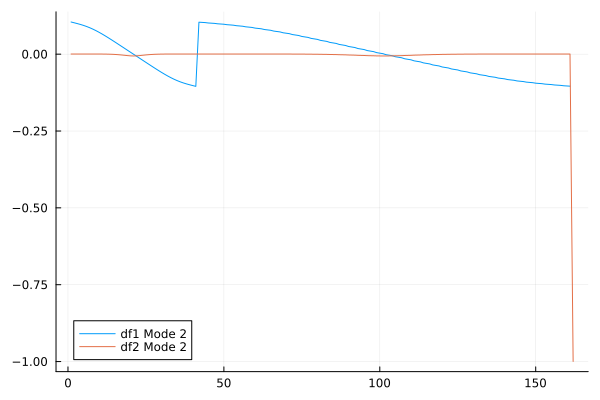

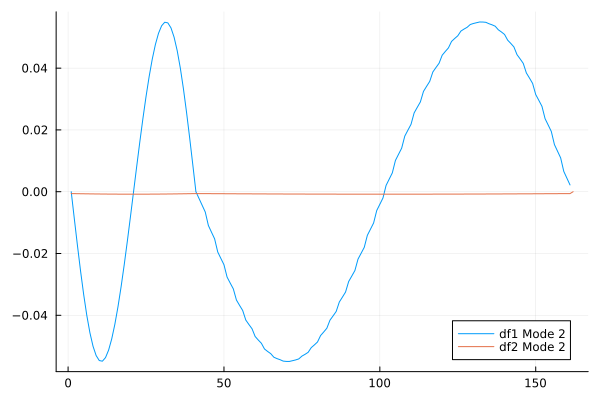

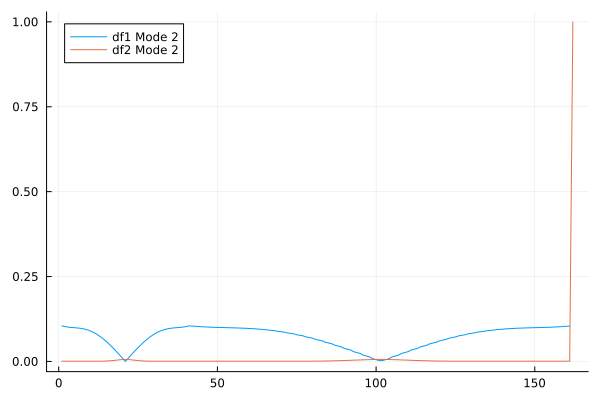

In [20]:
mode = 2
modeB = 1

df1_V = df1["dfWet"][:,"V"][mode]
df1_V = df1_V ./ sign(real(df1_V[1]))
df2_V = df2["dfWet"][:,"V"][modeB]
df2_V = df2_V ./ sign(real(df2_V[1]))


plot()
plot!(real(df1_V), label="df1 Mode $mode")
plot!(real(df2_V), label="df2 Mode $mode")
display(plot!())

plot()
plot!(imag(df1_V), label="df1 Mode $mode")
plot!(imag(df2_V), label="df2 Mode $mode")
display(plot!())

plot()
plot!(abs.(df1_V), label="df1 Mode $mode")
plot!(abs.(df2_V), label="df2 Mode $mode")
display(plot!())
